## Customer Segmentation

Customer segmentation is the process of dividing customers into groups based on common characteristics. This allows businesses to market to each group effectively.

Below is an example demonstrating customer segmentation using a synthetic dataset and K-Means clustering.

### 4. Apply K-Means Clustering

Now we apply the K-Means algorithm with the chosen optimal number of clusters to segment our customers. We will also calculate the Silhouette Score to evaluate the quality of the clustering.

In [ ]:
# Apply K-Means clustering with the optimal k
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Add the cluster labels to the original DataFrame
df['Cluster'] = clusters

print('Number of customers per cluster:')
display(df['Cluster'].value_counts().sort_index())

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(X, clusters)
print(f'\nSilhouette Score: {silhouette_avg:.2f}')

# Display the first few rows with cluster assignments
print('\nDataset with Cluster Assignments (first 5 rows):')
display(df.head())

Number of customers per cluster:


,count
Cluster,
0,58
1,39
2,47
3,34
4,22



Silhouette Score: 0.35

Dataset with Cluster Assignments (first 5 rows):


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2


### 5. Visualize the Clusters

To visualize the clusters, we can use Principal Component Analysis (PCA) to reduce the dimensionality of our data to 2 principal components, making it plottable. Then, we can create scatter plots to see how the clusters are separated based on key features.

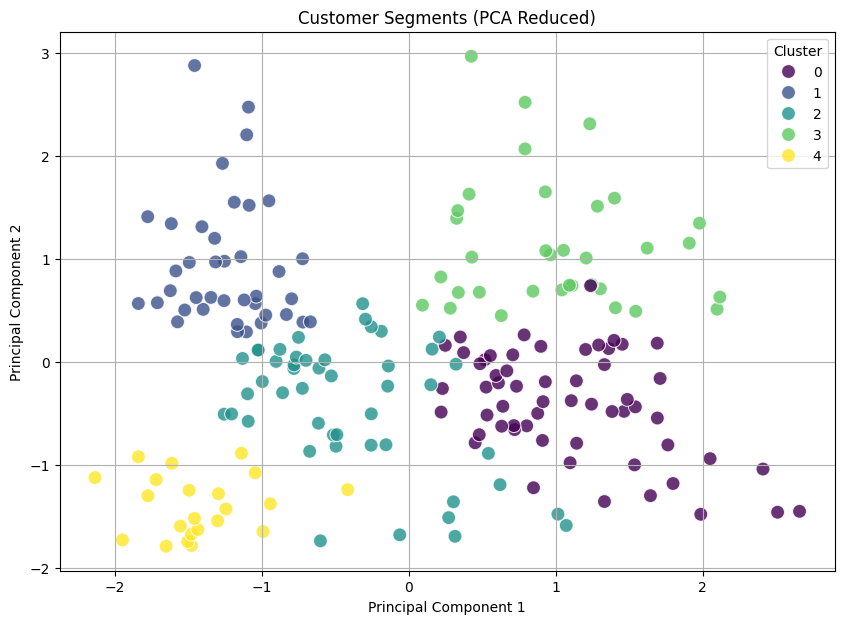

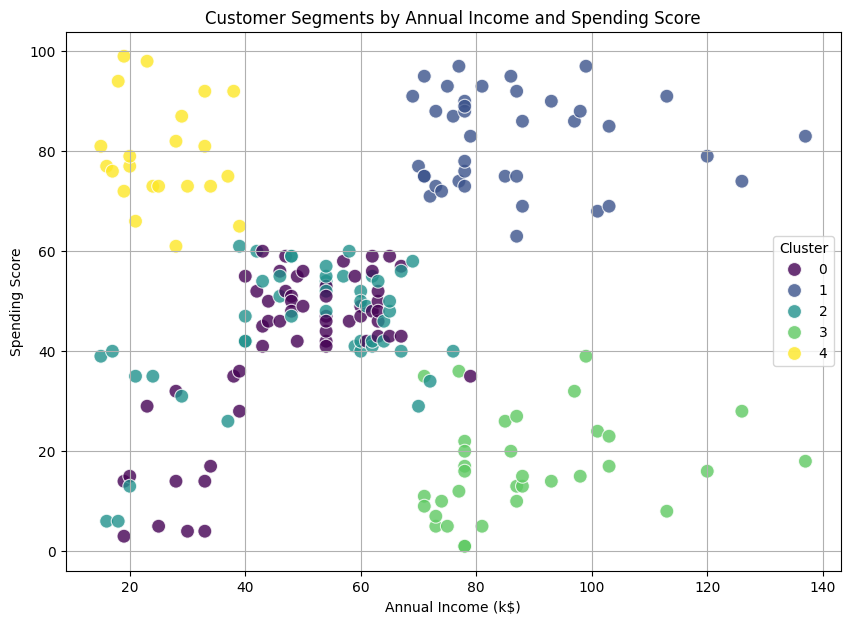


Cluster Characteristics:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.551724,48.482759,41.775862
1,32.692308,86.538462,82.128205
2,27.957447,50.000000,44.638298
3,41.264706,88.500000,16.764706
4,25.272727,25.727273,79.363636



Gender distribution per cluster:


Gender,Female,Male
Cluster,,
0,0.568966,0.431034
1,0.538462,0.461538
2,0.659574,0.340426
3,0.411765,0.588235
4,0.590909,0.409091


In [ ]:
# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = clusters

# Plot the clusters using PCA components
fig1 = plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Visualize clusters based on original features (e.g., Annual Income vs Spending Score)
fig2 = plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df,
                palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments by Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Analyze cluster characteristics (excluding 'Gender' from mean calculation)
print('\nCluster Characteristics:')
display(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())

print('\nGender distribution per cluster:')
display(df.groupby('Cluster')['Gender'].value_counts(normalize=True).unstack(fill_value=0))

### 1. Load the Mall Customers Data and Initial Exploration

Let's load the `Mall_Customers.csv` file into a pandas DataFrame and perform some initial exploration to understand its structure and content.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load the dataset
df_mall = pd.read_csv('Mall_Customers.csv')

# Display the first 5 rows
print('First 5 rows of the dataset:')
display(df_mall.head())

# Display basic information about the dataset
print('\nDataset Info:')
display(df_mall.info())

# Display descriptive statistics
print('\nDescriptive Statistics:')
display(df_mall.describe())

First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None


Descriptive Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 2. Data Preprocessing for Mall Customers Data

Now we will preprocess the `Mall_Customers.csv` data. This involves:
- Checking for missing values.
- One-hot encoding the 'Gender' column.
- Scaling the numerical features (`Age`, `Annual Income (k$)`, `Spending Score (1-100)`).
- Creating the feature matrix `X` for clustering.

In [ ]:
# Check for missing values
print('Missing values before preprocessing:')
display(df_mall.isnull().sum())

# Identify categorical and numerical columns for Mall_Customers.csv
categorical_cols_mall = ['Gender']
numerical_cols_mall = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# One-hot encode categorical features
encoder_mall = OneHotEncoder(sparse_output=False, drop='first') # drop='first' to avoid multicollinearity
encoded_features_mall = encoder_mall.fit_transform(df_mall[categorical_cols_mall])
encoded_df_mall = pd.DataFrame(encoded_features_mall, columns=encoder_mall.get_feature_names_out(categorical_cols_mall))

# Scale numerical features
scaler_mall = StandardScaler()
scaled_features_mall = scaler_mall.fit_transform(df_mall[numerical_cols_mall])
scaled_df_mall = pd.DataFrame(scaled_features_mall, columns=numerical_cols_mall)

# Combine preprocessed features into X
X = pd.concat([scaled_df_mall, encoded_df_mall], axis=1)

print('\nPreprocessed Data (X - first 5 rows):')
display(X.head())
print(f'Shape of preprocessed data (X): {X.shape}')

# Store original DataFrame for later use, if needed for analysis with clusters
df = df_mall.copy()

Missing values before preprocessing:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Preprocessed Data (X - first 5 rows):


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.0
1,-1.281035,-1.738999,1.195704,1.0
2,-1.352802,-1.700830,-1.715913,0.0
3,-1.137502,-1.700830,1.040418,0.0
4,-0.563369,-1.662660,-0.395980,0.0


Shape of preprocessed data (X): (200, 4)


### 3. Determine Optimal Number of Clusters (Elbow Method)

The Elbow Method helps in finding the optimal number of clusters for K-Means. We plot the sum of squared distances (inertia) for different numbers of clusters and look for an 'elbow' point where the decrease in inertia starts to slow down significantly.

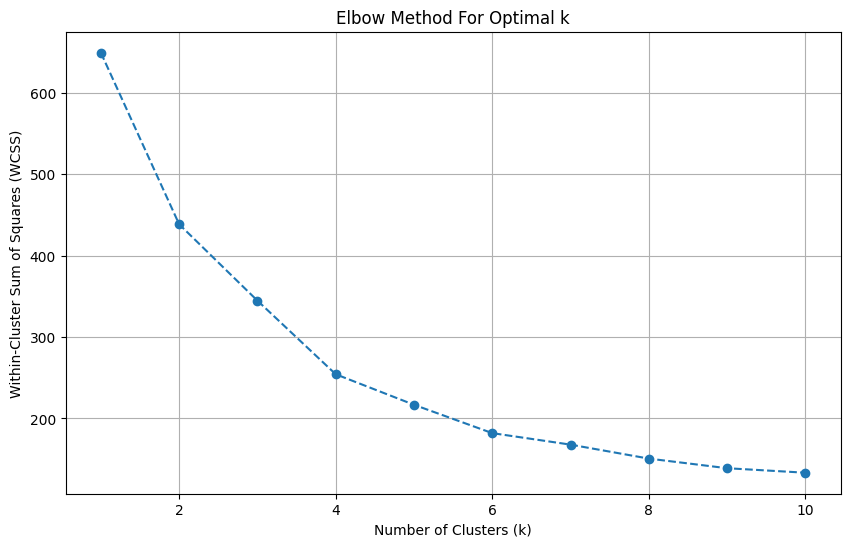

Suggested optimal number of clusters: 5


In [ ]:
wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

# Based on the plot, identify the 'elbow' point. A common choice for Mall_Customers dataset is k=5.
optimal_k = 5 # Adjust this based on your elbow plot
print(f'Suggested optimal number of clusters: {optimal_k}')

### 6. Visualize the Clusters

To visualize the clusters, we can use Principal Component Analysis (PCA) to reduce the dimensionality of our data to 2 principal components, making it plottable. Then, we can create scatter plots to see how the clusters are separated based on key features.

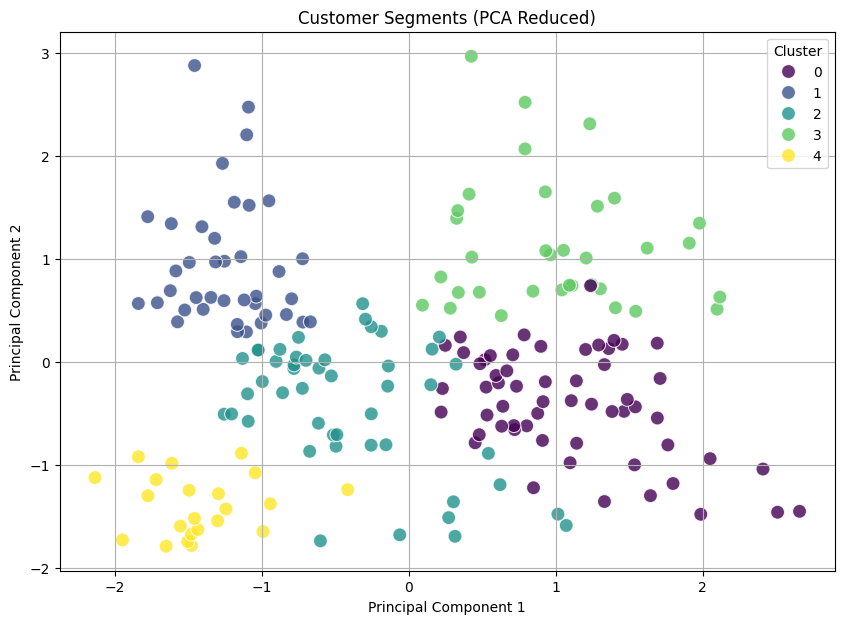

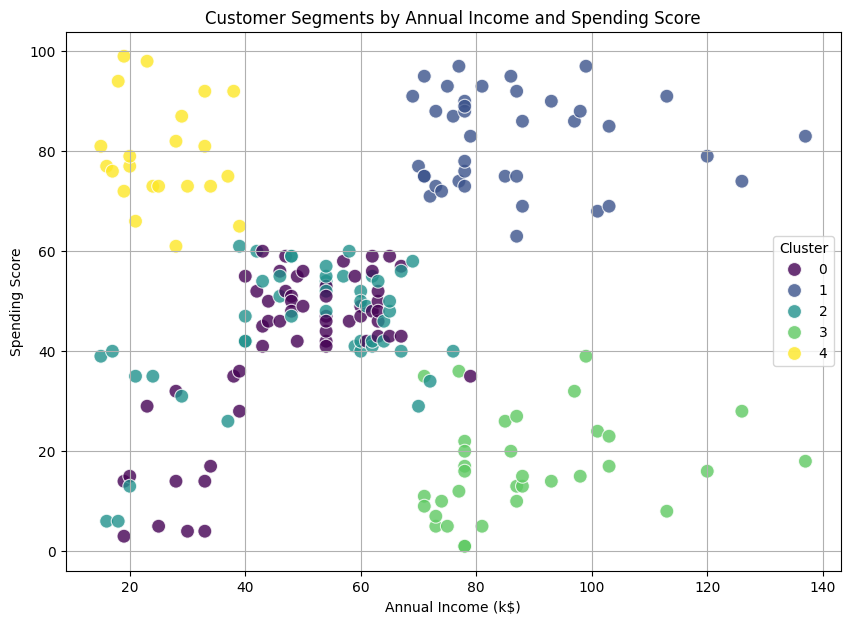


Cluster Characteristics:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.551724,48.482759,41.775862
1,32.692308,86.538462,82.128205
2,27.957447,50.000000,44.638298
3,41.264706,88.500000,16.764706
4,25.272727,25.727273,79.363636



Gender distribution per cluster:


Gender,Female,Male
Cluster,,
0,0.568966,0.431034
1,0.538462,0.461538
2,0.659574,0.340426
3,0.411765,0.588235
4,0.590909,0.409091


In [ ]:
# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = clusters

# Add the cluster labels to the original DataFrame for direct use in plotting and analysis
df['Cluster'] = clusters

# Plot the clusters using PCA components
fig1 = plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Visualize clusters based on original features (e.g., Annual Income vs Spending Score)
fig2 = plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df,
                palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments by Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Analyze cluster characteristics (excluding 'Gender' from mean calculation)
print('\nCluster Characteristics:')
display(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())

print('\nGender distribution per cluster:')
display(df.groupby('Cluster')['Gender'].value_counts(normalize=True).unstack(fill_value=0))

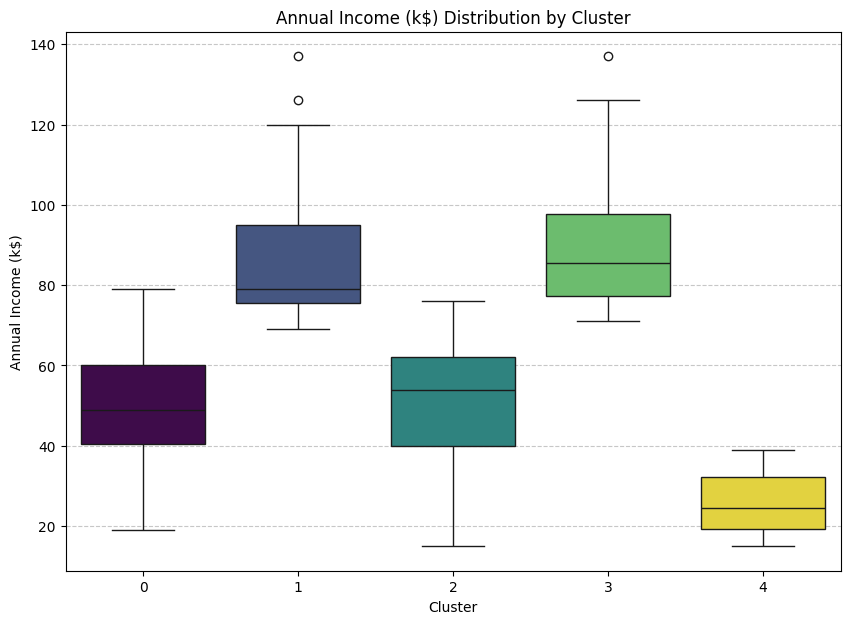

In [ ]:
# Unsupervised Learning

fig3 = plt.figure(figsize=(10, 7))
sns.boxplot(x='Cluster', y='Annual Income (k$)', hue='Cluster', data=df, palette='viridis', legend=False)
plt.title('Annual Income (k$) Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Annual Income (k$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

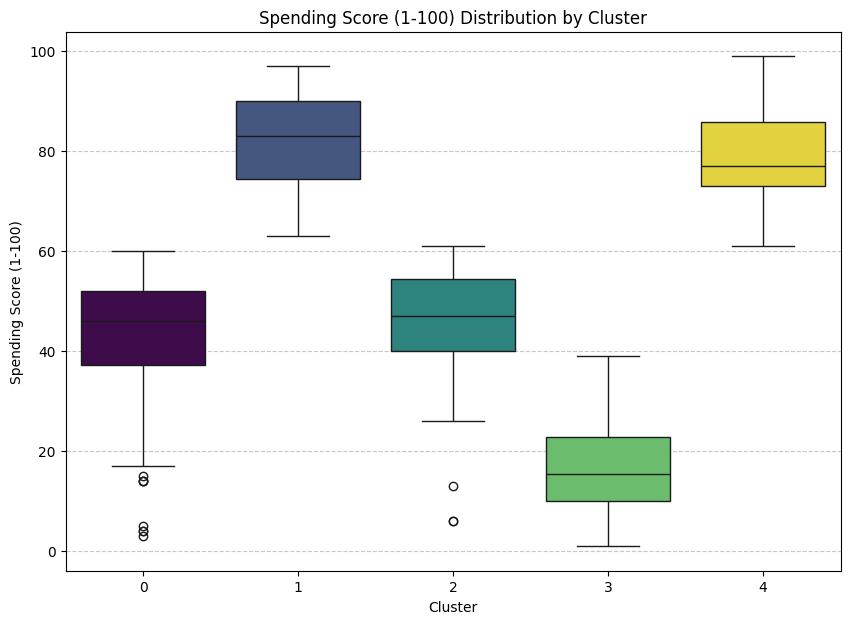

In [ ]:
fig4 = plt.figure(figsize=(10, 7))
sns.boxplot(x='Cluster', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', legend=False)
plt.title('Spending Score (1-100) Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Spending Score (1-100)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()